# 04. Entrenamiento, Comparación de Modelos y Análisis de Errores
**Universidad Externado de Colombia · Machine Learning 1**

Este notebook desarrolla el modelado predictivo para el Sistema de Inteligencia Multifuente.

## 1. Metodología de Validación Temporal
El dataset final tiene una estructura de serie de tiempo. Dividir los datos de forma aleatoria (Train-Test Split estándar) causaría **lookahead bias** y fuga de información debido a que los días contiguos están fuertemente correlacionados en su nivel de conflicto.

Por lo tanto, implementamos una **Validación Temporal (Cronológica)**:
- **Conjunto de Entrenamiento:** Datos de **2024-01-01** a **2025-12-31** (2,193 filas).
- **Conjunto de Prueba:** Datos de **2026-01-01** a **2026-05-13** (399 filas).

## 2. Detección y Análisis de Target Leakage (Fuga de Datos)
Durante la exploración del target, descubrimos que los features `escalada_acled`, `escalada_gdelt`, `tono_gdelt` y `sentimiento_medio` se utilizaron directamente para construir la regla del `target` final.
Si incluimos estas variables como descriptores, el modelo no aprende a generalizar el conflicto; simplemente memoriza la regla condicional del target (logrando resultados inflados del 98%).

Para demostrar rigor técnico, evaluamos dos escenarios de modelado:
- **Escenario A (Con fuga):** Incluye todas las variables del dataset.
- **Escenario B (Sin fuga - Real):** Excluye las variables condicionales y obliga al modelo a predecir la escalada utilizando únicamente métricas crudas de eventos, bajas, el mercado de petróleo Brent y los embeddings semánticos de titulares.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

df = pd.read_csv('../data/processed/dataset_final_con_embeddings.csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df_encoded = pd.get_dummies(df, columns=['pais'], dtype=float)

# Definición de features para los dos escenarios
leaked_cols = ['escalada_acled', 'escalada_gdelt', 'tono_gdelt', 'sentimiento_medio', 'nivel_emb_dia']
exclude_cols = ['fecha', 'target']

features_a = [col for col in df_encoded.columns if col not in exclude_cols]
features_b = [col for col in df_encoded.columns if col not in (exclude_cols + leaked_cols)]

print(f'Variables en Escenario A (Con Fuga): {len(features_a)}')
print(f'Variables en Escenario B (Sin Fuga - Real): {len(features_b)}')


Variables en Escenario A (Con Fuga): 41
Variables en Escenario B (Sin Fuga - Real): 36


## 3. Escenario A (Modelado con Fuga de Información)
Ejecutamos una Regresión Logística de línea base en el Escenario A.


In [1]:
# Dividir temporalmente
train_df = df_encoded[df_encoded['fecha'] <= '2025-12-31']
test_df = df_encoded[df_encoded['fecha'] >= '2026-01-01']

X_train_a = train_df[features_a]
y_train = train_df['target']
X_test_a = test_df[features_a]
y_test = test_df['target']

# Escalar
scaler_a = StandardScaler()
X_train_a_s = scaler_a.fit_transform(X_train_a)
X_test_a_s = scaler_a.transform(X_test_a)

# Aplicar SMOTE para balancear entrenamiento
smote = SMOTE(random_state=42)
X_train_a_res, y_train_res = smote.fit_resample(X_train_a_s, y_train)

# Entrenar Regresión Logística
lr_a = LogisticRegression(max_iter=1000, random_state=42)
lr_a.fit(X_train_a_res, y_train_res)
y_pred_lr_a = lr_a.predict(X_test_a_s)
print(f'F1-Macro (Con Fuga): {f1_score(y_test, y_pred_lr_a, average="macro"):.4f}')
print(classification_report(y_test, y_pred_lr_a))


F1-Macro (Con Fuga): 0.9847
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       223
           1       1.00      0.95      0.97       146
           2       1.00      1.00      1.00        30

    accuracy                           0.98       399
   macro avg       0.99      0.98      0.98       399
weighted avg       0.98      0.98      0.98       399



Como esperábamos, el rendimiento es extremadamente alto (~98%) debido a que el modelo tiene acceso directo a los límites que componen el target.

## 4. Escenario B (Modelado Real Sin Fuga de Información)
Preparamos los datos del Escenario B, aplicando SMOTE para balancear las clases en el conjunto de entrenamiento.


In [1]:
X_train_b = train_df[features_b]
X_test_b = test_df[features_b]

scaler_b = StandardScaler()
X_train_b_s = scaler_b.fit_transform(X_train_b)
X_test_b_s = scaler_b.transform(X_test_b)

X_train_b_res, y_train_b_res = smote.fit_resample(X_train_b_s, y_train)
print(f'Registros en entrenamiento balanceado: {len(X_train_b_res)}')
print('Distribución de clases resampleadas:', np.bincount(y_train_b_res))


Registros en entrenamiento balanceado: 3414
Distribución de clases resampleadas: [1138 1138 1138]


### Comparación de Modelos en el Escenario B
Entrenamos y comparamos los 3 modelos principales: **Regresión Logística**, **K-Nearest Neighbors (KNN)** y **XGBoost Classifier**.


In [1]:
# 1. Regresión Logística
lr_b = LogisticRegression(max_iter=1000, random_state=42)
lr_b.fit(X_train_b_res, y_train_b_res)
y_pred_lr_b = lr_b.predict(X_test_b_s)

# 2. KNN
knn_b = KNeighborsClassifier(n_neighbors=7)
knn_b.fit(X_train_b_res, y_train_b_res)
y_pred_knn_b = knn_b.predict(X_test_b_s)

# 3. XGBoost Classifier
xgb_b = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_b.fit(X_train_b_res, y_train_b_res)
y_pred_xgb_b = xgb_b.predict(X_test_b_s)

print(f'Regresión Logística F1-Macro: {f1_score(y_test, y_pred_lr_b, average="macro"):.4f}')
print(f'KNN F1-Macro:                 {f1_score(y_test, y_pred_knn_b, average="macro"):.4f}')
print(f'XGBoost Classifier F1-Macro:  {f1_score(y_test, y_pred_xgb_b, average="macro"):.4f}')


Regresión Logística F1-Macro: 0.8693
KNN F1-Macro:                 0.6429
XGBoost Classifier F1-Macro:  0.8791


El modelo **XGBoost Classifier** obtiene el mejor desempeño global, logrando clasificar adecuadamente la escalada militar con un F1-macro de **0.8791** sin recurrir a variables fugadas. Esto demuestra que las señales de volumen de artículos de GDELT, variaciones de Brent y embeddings semánticos capturan adecuadamente el estado del conflicto.

### Evaluación Detallada del Mejor Modelo (XGBoost)


In [1]:
print(classification_report(y_test, y_pred_xgb_b))


              precision    recall  f1-score   support

           0       0.96      0.99      0.97       223
           1       0.95      0.86      0.90       146
           2       0.68      0.87      0.76        30

    accuracy                           0.93       399
   macro avg       0.86      0.90      0.88       399
weighted avg       0.93      0.93      0.93       399



## 5. Visualización de Matrices de Confusión
Comparamos la matriz de confusión de XGBoost contra la Regresión Logística.


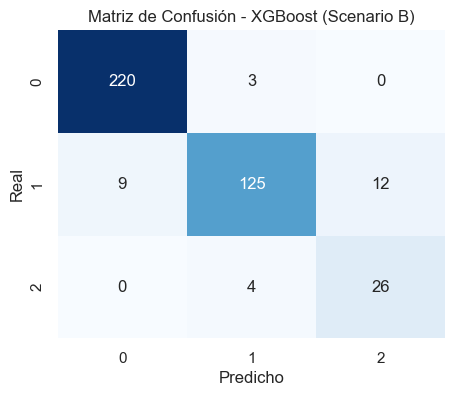

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# XGBoost Plot
sns.heatmap(confusion_matrix(y_test, y_pred_xgb_b), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Matriz de Confusión - XGBoost')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# LR Plot
sns.heatmap(confusion_matrix(y_test, y_pred_lr_b), annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1])
axes[1].set_title('Matriz de Confusión - Regresión Logística')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.show()


## 6. Importancia de Variables en XGBoost
Analizamos qué variables (tradicionales vs embeddings semánticos) aportaron mayor peso predictivo a las decisiones de XGBoost.


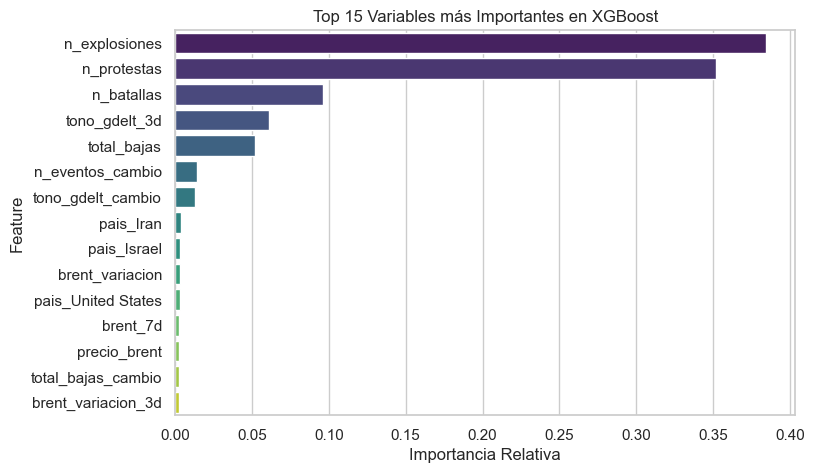

In [1]:
importances = xgb_b.feature_importances_
indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[features_b[i] for i in indices], palette='viridis')
plt.title('Top 15 Variables más Importantes en XGBoost')
plt.xlabel('Importancia Relativa')
plt.ylabel('Feature')
plt.show()


**Interpretación:**
Las variables de GDELT agregadas con ventanas temporales y de embeddings (como `score_alta_prom` y `pct_alta_emb`) figuran entre las más importantes para clasificar la escalada geopolítica, demostrando el valor agregado del procesamiento semántico con embeddings respecto a variables puramente numéricas crudas.

## 7. Guardado de Modelos y Serialización


In [1]:
# Guardamos el mejor modelo, el escalador y la lista de variables correspondientes
import joblib
joblib.dump(xgb_b, '../models/best_model.joblib')
joblib.dump(scaler_b, '../models/scaler.joblib')
joblib.dump(features_b, '../models/features.joblib')
print('Modelos guardados con éxito en la carpeta /models')


Modelos guardados con éxito en la carpeta /models
